# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt# importar librerías

In [2]:
instacart_orders = pd.read_csv('/datasets/instacart_orders.csv', sep=";")
products = pd.read_csv('/datasets/products.csv', sep=";")
aisles = pd.read_csv('/datasets/aisles.csv', sep=";")
departments = pd.read_csv('/datasets/departments.csv', sep=";")
order_products = pd.read_csv('/datasets/order_products.csv', sep=";") 

# leer conjuntos de datos en los DataFrames
#Se enuncian de acuerdo a los nombres del archivo, para mayor claridad del código

In [3]:
instacart_orders.info() #Información del Dataframe instacart_orders
print ()
print()
instacart_orders.isnull().sum() #Confirmación de los valores no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB




order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28819
dtype: int64

In [4]:
print(instacart_orders.head()) #Mostramos las primeras 5 filas 
print ()
print()
instacart_orders.describe() #Mostramos las estadisticas del Dataframe

   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  




,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,4.789670e+05,478967.000000,478967.000000,478967.000000,478967.000000,450148.000000
mean,1.709947e+06,102966.537475,17.157808,2.775058,13.446676,11.101751
std,9.869480e+05,59525.328991,17.704688,2.045869,4.224986,9.189975
min,4.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000
25%,8.564685e+05,51414.000000,5.000000,1.000000,10.000000,4.000000
50%,1.709522e+06,102633.000000,11.000000,3.000000,13.000000,7.000000
75%,2.562990e+06,154419.000000,23.000000,5.000000,16.000000,15.000000
max,3.421079e+06,206209.000000,100.000000,6.000000,23.000000,30.000000


In [5]:
orders_per_day = instacart_orders['order_dow'].value_counts().sort_index() #Suma de los pedidos por día 0 (domingo) a 6 (sabado)
print (orders_per_day)
print ()
print("Media:", round(orders_per_day.mean())) #Promedio de los pedidos por día
print("Desviación estándar:", round(orders_per_day.std())) #Desviación estándar de los pedidos por día
print("Mínimo:", orders_per_day.min()) #Valor minimo de los pedidos por día
print("Máximo:", orders_per_day.max()) #Valor máximo de los pedidos por día

0    84090
1    82185
2    65833
3    60912
4    59810
5    63488
6    62649
Name: order_dow, dtype: int64

Media: 68424
Desviación estándar: 10246
Mínimo: 59810
Máximo: 84090


In [6]:
orders_per_hour = instacart_orders['order_hour_of_day'].value_counts().sort_index() #Suma de los pedidos por hora
print (orders_per_hour)
print ()
print("Media:", round(orders_per_hour.mean())) #Promedio de los pedidos por hora
print("Desviación estándar:", round(orders_per_hour.std())) #Desviación estándar de los pedidos por hora
print("Mínimo:", orders_per_hour.min()) #Valor minimo de los pedidos por hora
print("Máximo:", orders_per_hour.max()) #Valor máximo de los pedidos por hora

0      3180
1      1763
2      1004
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_hour_of_day, dtype: int64

Media: 19957
Desviación estándar: 15984
Mínimo: 765
Máximo: 40578


In [7]:
products.info() #Información del Dataframe products
print()
print()
products.isnull().sum() #Confirmación de los valores no nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB




product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

In [8]:
print(products.head()) #Mostramos las primeras 5 filas 
print ()
print()
products.describe() #Mostramos las estadisticas del Dataframe

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  




,product_id,aisle_id,department_id
count,49694.000000,49694.000000,49694.000000
mean,24847.500000,67.773192,11.728478
std,14345.566475,38.317265,5.850314
min,1.000000,1.000000,1.000000
25%,12424.250000,35.000000,7.000000
50%,24847.500000,69.000000,13.000000
75%,37270.750000,100.000000,17.000000
max,49694.000000,134.000000,21.000000


In [9]:
print(products['aisle_id'].value_counts().sort_values(ascending=False)) # Cantidad de productos por pasillo
print()
print()
productos_por_pasillo = products.groupby('aisle_id')['product_id'].count().reset_index(name='num_products_aisle') #Agrupa y suma los productos por pasillo, convierte en un Dataframe
productos_por_pasillo['num_products_aisle'].describe() #Calcula estadísticas de la agrupación de productos por pasillo

100    1258
45     1246
37     1091
47     1038
120    1026
       ... 
113      47
82       44
32       32
68       26
18       12
Name: aisle_id, Length: 134, dtype: int64




count     134.000000
mean      370.850746
std       267.020106
min        12.000000
25%       179.750000
50%       306.500000
75%       497.500000
max      1258.000000
Name: num_products_aisle, dtype: float64

In [10]:
print(products['department_id'].value_counts().sort_values(ascending=False)) # Cantidad de productos por departamento
print()
print()
productos_por_departamento = products.groupby('department_id')['product_id'].count().reset_index(name='num_products_department') #Agrupa y suma los productos por departamento, convierte en un Dataframe
productos_por_departamento['num_products_department'].describe() #Calcula estadísticas de la agrupación de productos por departamento

11    6564
19    6264
13    5372
7     4366
1     4008
16    3449
17    3085
15    2092
9     1858
4     1684
3     1516
20    1322
21    1258
6     1139
14    1117
18    1081
5     1054
8      972
12     907
2      548
10      38
Name: department_id, dtype: int64




count      21.000000
mean     2366.380952
std      1914.585372
min        38.000000
25%      1081.000000
50%      1516.000000
75%      3449.000000
max      6564.000000
Name: num_products_department, dtype: float64

In [11]:
order_products.info(show_counts=True) #Información del Dataframe order_products
print()
print()
order_products.isnull().sum() #Confirmación de los valores no nulos, puesto que no parecen con info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB




order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64

In [12]:
print(order_products.head()) #Mostramos las primeras 5 filas
print ()
print() 
order_products.describe() #Mostramos las estadisticas del Dataframe

   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1




,order_id,product_id,add_to_cart_order,reordered
count,4.545007e+06,4.545007e+06,4.544171e+06,4.545007e+06
mean,1.711166e+06,2.558084e+04,8.351669e+00,5.905025e-01
std,9.850955e+05,1.409552e+04,7.080368e+00,4.917411e-01
min,4.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,8.608170e+05,1.353500e+04,3.000000e+00,0.000000e+00
50%,1.711530e+06,2.527200e+04,6.000000e+00,1.000000e+00
75%,2.561311e+06,3.793500e+04,1.100000e+01,1.000000e+00
max,3.421079e+06,4.969400e+04,6.400000e+01,1.000000e+00


In [13]:
aisles.info() #Información del Dataframe aisles
print()
print()
print(aisles.head()) #Mostramos las primeras 5 filas
print ()
print()
aisles.describe() #Mostramos las estadisticas del Dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation




,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


In [14]:
departments.info() #Información del Dataframe departments
print()
print()
print(departments.head()) #Mostramos las primeras 5 filas
print ()
print()
departments.describe() #Mostramos las estadisticas del Dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes


   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol




,department_id
count,21.000000
mean,11.000000
std,6.204837
min,1.000000
25%,6.000000
50%,11.000000
75%,16.000000
max,21.000000


## Conclusiones

En la revisión preliminar de los archivos del conjunto de datos de Instacart (instacart_orders.csv, products.csv, aisles.csv, departments.csv y order_products.csv) se identificaron patrones comunes que evidencian inconsistencias en el momento de su lectura con la librería pandas. 

De forma consistente en los cinco archivos analizados, se evidencia que el problema principal radica en el separador de campos utilizado en los archivos CSV, el cual es punto y coma ( ; ) en lugar de la coma (,) que pandas usa por defecto en pd.read_csv().

Como consecuencia, cada conjunto de datos se está leyendo con una sola columna y con tipos de datos incorrectos, lo que impide la ejecución de análisis descriptivos y relacionales.

Este hallazgo es clave para agregar al código el separador (sep=';'), lo que permitirá restaurar la estructura tabular original de los archivos, conservar los tipos de datos adecuados y habilitar el análisis exploratorio y la limpieza de datos en pasos posteriores.

De acuerdo a la información que se encuentra en cada DataFrame, se tiene la siguiente información sobre cada archivo:

1. instacart_orders.csv: Este archivo reúne 478.967 entradas con información sobre los pedidos realizados por los clientes en la plataforma Instacart. Cada registro representa una orden individual e incluye detalles como el número de pedido (478.967 no nulos, entero), el cliente que lo realizó (478.967 no nulos, entero), la frecuencia de compra (478.967 no nulos, entero), el día (478.967 no nulos, entero) y la hora (478.967 no nulos, entero) en que se efectuó, así como el tiempo transcurrido desde la compra anterior (450.148 no nulos, 28.819 valores ausentes, flotante). 

A continuación, se realizará una revisión detallada de cada columna para comprender el significado de las variables y su aporte al análisis:

- order_id y user_id: Funcionan como identificadores únicos, por lo que no aportan información estadística directa sobre los comportamientos de compra. Sin embargo, son esenciales para vincular pedidos con usuarios y para realizar análisis relacionales o de fidelidad del cliente.
  
- order_number: Los usuarios han realizado en promedio alrededor de 17 pedidos en la plataforma, aunque algunos llegan a más de 100, lo cual sugiere la existencia de clientes altamente recurrentes.
Los percentiles muestran que la mitad de los clientes ha hecho entre 5 y 23 pedidos, lo que refleja una base de usuarios con distintos niveles de fidelidad y frecuencia de compra.

- order_dow (día de la semana del pedido): En este caso, las estadísticas generadas por la función describe() no aportan información significativa, ya que los valores de esta columna (de 0 a 6) solo representan los días de la semana y no cantidades de pedidos. Sin embargo, al realizar un conteo del número de órdenes por cada día, fue posible obtener datos más útiles para el análisis.
De acuerdo con los resultados, se registraron 84.090 pedidos el día 0 (domingo), mientras que el número más bajo se presentó el día 4 (jueves) con 59.810 pedidos. El promedio semanal fue de 68.424 pedidos por día, con una desviación estándar de 10.246, lo que indica una variación moderada entre los distintos días de la semana.

- order_hour_of_day (hora del día en que se hizo el pedido): Aunque el método describe() nos entrega estadísticas básicas (como media, desviación estándar y rango), en este caso no resultan del todo representativas, ya que los valores corresponden a horas del día (una variable temporal y cíclica) y no a una medida continua. 
En cambio, al agrupar los pedidos por hora (value_counts()), encontramos que el mayor número de pedidos ocurre a las 10:00 a.m. (40.578 pedidos) y el menor a las 4:00 a.m. (765 pedidos). El promedio de pedidos por hora fue de 19.957, con una desviación estándar de 15.984, lo que representa un coeficiente de variación del 80%. Esto indica una alta dispersión en los pedidos a lo largo del día, es decir, hay horas con una actividad muy intensa y otras con muy poca participación.

- days_since_prior_order (días transcurridos desde el pedido anterior): Esta variable presenta 28.819 valores ausentes, que probablemente corresponden a los primeros pedidos de cada usuario (esto se confirmará durante el proceso de limpieza de datos).
Con los datos que se tiene, en promedio, los usuarios repiten sus compras cada 11 días, con una alta variabilidad (desviación estándar de 9 días). La mitad de los pedidos se repiten entre 4 y 15 días después del anterior, lo que sugiere comportamientos de recompra diversos. El valor máximo de 30 días sugiere que hay usuarios que compran solo una vez al mes.

2. products.csv: Este archivo reúne 49.694 entradas con información sobre los productos disponibles en la plataforma Instacart. Cada registro representa un artículo único (49.694 no nulos, entero), identificado por su nombre (48.436 no nulos, 1.258 valores ausentes, object) y por los códigos que lo asocian con un pasillo (49.694 no nulos, entero) y un departamento (49.694 no nulos, entero) específicos.
Este archivo es fundamental para explorar la variedad de la oferta, clasificar los productos por tipo o categoría y vincular la información de artículos con los pedidos y los comportamientos de compra.

- product_id: Funciona como un identificador único de cada producto, por lo que no aporta información estadística directa sobre los comportamientos de compra. Sin embargo, es esencial para vincular los productos con los pedidos y realizar análisis de oferta o rotación de artículos.
  
- product_name: Corresponde al nombre del producto, por lo que su valor es descriptivo y no numérico. Se identifican 1.258 valores ausentes, lo que podría deberse a errores de registro, productos recientemente incorporados sin nombre asignado o inconsistencias en la carga de datos. Aunque no aporta información estadística directa, esta variable es clave para identificar los artículos y realizar análisis de frecuencia o popularidad de productos específicos.

- aisle_id: Representa el pasillo o subcategoría donde se ubica el producto.  Tiene 134 pasillos que contienen en promedio 371 productos. Existe una alta variabilidad entre ellos (desviación estándar de 267). El pasillo con mayor variedad cuenta con 1.258 productos, mientras que el de menor tamaño tiene solo 12.
Los percentiles indican que el 50% de los pasillos albergan entre 180 y 498 productos, lo que refleja una distribución desigual de la oferta: algunos pasillos concentran una gran cantidad de artículos, mientras que otros tienen una gama más limitada.

- department_id: Indica el departamento o categoría general a la que pertenece cada producto. La base de datos cuenta con 21 departamentos, que reúnen en promedio 2.366 productos cada uno. Se observa una alta variabilidad entre ellos (desviación estándar de 1.915), lo que evidencia diferencias notables en la cantidad de artículos por departamento.
El departamento con mayor variedad agrupa 6.564 productos, mientras que el más pequeño solo tiene 38.
Los percentiles muestran que el 50% de los departamentos contienen entre 1.081 y 3.449 productos, esto refleja una estructura de oferta heterogénea, donde algunos departamentos concentran una gran cantidad de productos, mientras que otros presentan una gama más limitada, posiblemente asociada a categorías más específicas o de nicho.

3. order_products.csv: Este archivo contiene 4.545.007 entradas, cada registro representa un producto (4.545.007 no nulos, entero)   dentro de un pedido (4.544.171 no nulos,  836 valores ausentes*, float), indicando en qué posición fue añadido al carrito (4.545.007 no nulos, entero)  y si ha sido solicitado previamente por el mismo cliente (4.545.007 no nulos, entero) .
   
*Pandas a veces no muestra en el método .info() la columna “Non-Null Count”, cuando el Dataframe tiene demasiadas filas, por lo que se incluye show_counts=True en info(). Tambien puede ocurrir cuando la mayoría de las columnas están completas, incluso si hay algunas con pocos valores nulos. En este caso, para add_to_cart_order se tiene 836 valores ausentes que corresponden al 0,018% del total de los datos registrados, posiblemente por errores de carga o productos eliminados antes de finalizar el pedido.

- order_id y product_id: Funcionan como identificadores únicos, por lo que no aportan información estadística directa sobre los comportamientos de compra. Sin embargo, son esenciales para vincular pedidos con usuarios y para realizar análisis relacionales o de fidelidad del cliente. 

- add_to_cart_order: Esta variable indica la posición en que un producto fue añadido al carrito dentro de un pedido. El valor mínimo es 1 y el máximo 64, lo que sugiere que algunos clientes realizaron pedidos con hasta 64 artículos distintos. En promedio, se agregan 8 productos por pedido. Los percentiles revelan que la mitad de los usuarios incluye entre 3 y 11 productos, con una desviación estándar de 7.08, lo que evidencia una alta dispersión en los tamaños de compra. En conjunto, estos datos muestran que la mayoría de los pedidos corresponden a compras pequeñas o medianas, consistentes con hábitos de consumo frecuente o reposiciones rápidas.

- reordered: Es una variable binaria que indica si un producto fue pedido por primera vez (0) o vuelto a pedir (1). El valor mínimo es 0 y el máximo 1, con un promedio de 0.5905, lo que revela que el 59,05% de los productos fueron reordenados por los clientes en alguna ocasión. Esto refleja una alta tasa de recompra, asociada a la fidelidad del consumidor y a hábitos de consumo frecuentes. La baja desviación estándar (0.49) es coherente con la naturaleza binaria de la variable, y confirma una distribución relativamente equilibrada entre artículos nuevos y repetidos.

4. aisles.csv: Este archivo reúne 134 entradas con la lista de los pasillos o secciones de la tienda, donde cada pasillo (134 no nulos, entero) agrupa productos de una misma categoría   (134 no nulos, object). Este archivo facilita la clasificación temática de los productos y permite realizar análisis comparativos por tipo de artículos o áreas de venta dentro del supermercado.
   
- aisle_id y aisle: Funcionan como identificadores y etiquetas únicas, por lo que no aportan información estadística sobre comportamientos de compra, pero son clave para establecer relaciones entre productos, departamentos y patrones de fidelidad del cliente.

5. departments.csv: Este archivo contiene 21 entradas, que representan los distintos departamentos de productos en los que se organiza el catálogo de Instacart. Cada registro incluye un identificador único del departamento (department_id, 21 no nulos, entero) y su nombre (department, 21 no nulos, object). Junto con los pasillos y los productos, este dataset contribuye a construir una estructura jerárquica del inventario, útil para análisis por categorías, gestión del surtido y estrategias comerciales.
   
- department_id y department: Actúan como identificadores y etiquetas únicas, por lo que no aportan información estadística directa sobre comportamientos de compra, pero son fundamentales para establecer relaciones entre productos, pasillos y patrones de fidelidad del cliente.



# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

1. Verificación de tipos de datos
- Revisar que todas las columnas contegan el tipo de datos apropiado
- Corregir tipos incorrectos si se encuentran


2. Manejo de valores ausentes
En el Paso 1. se identificaron los valores ausentes, asi:
- instacart_orders:  28,819 nulos en days_since_prior_order
- products: 1,258 nulos en product_name  
- order_products: 836 nulos en add_to_cart_order
  
De acuerdo a esto en este paso se debe decidir la estrategia para cada caso:
- Eliminar filas/columnas con muchos nulos
- Completar con valores apropiados (media, mediana, moda)
- Mantener si son nulos lógicos

Y Justificar cada decisión.


3. Eliminación de duplicados
- Buscar duplicados en cada DataFrame usando .duplicated().sum()
- Analizar si son duplicados reales o registros válidos repetidos
- Eliminar duplicados verdaderos
- Documentar cuántos se eliminaron



## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [15]:
#Verifico y corrigo los tipos de datos

#Encontramos que todos son tipo int64, a excepción de days_since_prior_order es de tipo float64, y es necesario que este en este formato porque para manejar los valores ausentes.

In [16]:
instacart_orders.duplicated().sum() #Verifico si hay filas duplicadas

15

In [17]:
orders_duplicated = instacart_orders[instacart_orders.duplicated()] #Guardo en una nueva variable las filas duplicadas
print(orders_duplicated) #Ver las filas duplicadas

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48          3 

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

Tenemos 15 filas duplicadas, donde se evidencia que todos los pedidos duplicados son del miércoles a las 2:00 a.m.

In [18]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

# Verificar pedidos del miércoles (día 3) a las 2:00 horas

dia_especifico = 3   # miércoles
hora_especifica = 2  # 2:00 AM

pedidos_miercoles_2am = instacart_orders[
    (instacart_orders['order_dow'] == dia_especifico) &
    (instacart_orders['order_hour_of_day'] == hora_especifica)
]

print(f"Pedidos el día {dia_especifico} a las {hora_especifica}:00 horas:")
print(f"Total de pedidos: {len(pedidos_miercoles_2am)}")  #Cantidad de pedidos totales el miércoles a las 2a.m.
print(pedidos_miercoles_2am.head())

Pedidos el día 3 a las 2:00 horas:
Total de pedidos: 121
       order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838    2766110   162084            41          3                  2   
5156    2190225   138285            18          3                  2   
15506    553049    58599            13          3                  2   
18420    382357   120200            19          3                  2   
24691    690242    77357             2          3                  2   

       days_since_prior_order  
4838                     16.0  
5156                     11.0  
15506                     7.0  
18420                    11.0  
24691                     9.0  


In [19]:
# Ver estadísticas de esos pedidos específicos
print("Estadísticas de los pedidos:")
print(pedidos_miercoles_2am.describe())

# Ver si hay patrones en los usuarios
print(f"Usuarios únicos: {pedidos_miercoles_2am['user_id'].nunique()}") #Cantidad de usuarios únicos el miércoles a las 2a.m.
print(f"Pedidos únicos: {pedidos_miercoles_2am['order_id'].nunique()}") #Cantidad de pedidos únicos el miércoles a las 2a.m.

Estadísticas de los pedidos:
           order_id        user_id  order_number  order_dow  \
count  1.210000e+02     121.000000    121.000000      121.0   
mean   1.559747e+06   97662.173554     17.190083        3.0   
std    9.295876e+05   58662.258670     18.266688        0.0   
min    1.910000e+02    3510.000000      1.000000        3.0   
25%    7.369830e+05   50898.000000      5.000000        3.0   
50%    1.496645e+06   85622.000000     10.000000        3.0   
75%    2.282673e+06  144464.000000     24.000000        3.0   
max    3.389820e+06  204961.000000     96.000000        3.0   

       order_hour_of_day  days_since_prior_order  
count              121.0               114.00000  
mean                 2.0                12.54386  
std                  0.0                 9.85123  
min                  2.0                 1.00000  
25%                  2.0                 4.25000  
50%                  2.0                 9.00000  
75%                  2.0                18.750

¿Qué sugiere este resultado?

De acuerdo a la información encontrada el miercoles a las 2 a.m. en el Dataframe se tiene 121 pedidos registrados, de los cuales se puede evidenciar que hay 106 pedidos únicos, quedando así 15 pedidos, que es el número de pedidos duplicados.

El hecho de que los 15 registros duplicados se concentren el mismo dia y a la misma hora sugiere una posible duplicación manual o error operativo, probablemente por fatiga, repetición involuntaria del proceso o inestabilidad del sistema en horas de baja carga. Dado que no se presentan duplicados en otros momentos, el patrón indica una anomalía puntual más que un comportamiento habitual de los usuarios o del sistema.

In [20]:
pedidos_miercoles_2am_sin_duplicados = pedidos_miercoles_2am.drop_duplicates() # Eliminar las filas duplicadas del DataFrame
print(pedidos_miercoles_2am_sin_duplicados) #Se observa que quedaro 106 filas


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [21]:
print(f"Total de filas duplicadas después de limpiar: {pedidos_miercoles_2am_sin_duplicados.duplicated().sum()}")
# Verifica nuevamente que no existan duplicados

Total de filas duplicadas después de limpiar: 0


In [22]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos


# Verificar si hay order_id duplicados
duplicados_order_id = pedidos_miercoles_2am['order_id'].duplicated().sum()
print(f"Total de order_id duplicados: {duplicados_order_id}")

# Ver cuántas veces aparece cada order_id (solo los que están duplicados)
repetidos_2am = pedidos_miercoles_2am['order_id'].value_counts()
repetidos_2am = repetidos_2am[repetidos_2am > 1]
print("\nOrder_id duplicados y su número de repeticiones:")
print(repetidos_2am)


Total de order_id duplicados: 15

Order_id duplicados y su número de repeticiones:
2282673    2
1919531    2
1286742    2
1782114    2
2160484    2
391768     2
2845099    2
1112182    2
1918001    2
1021560    2
408114     2
794638     2
467134     2
2125197    2
2232988    2
Name: order_id, dtype: int64


In [23]:

duplicados_detalle_2am = pedidos_miercoles_2am[pedidos_miercoles_2am['order_id'].isin(repetidos_2am.index)] # Verifico si los order_id duplicados tienen distintos productos
print(duplicados_detalle_2am.head(20))


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
30371    1918001   188546            14          3                  2   
99462     794638    50898            24          3                  2   
119251    408114    68324             4          3                  2   
142258   2845099    31189            11          3                  2   
145574    794638    50898            24          3                  2   
164581   1112182   202304            84          3                  2   
200059   1782114   106752             1          3                  2   
204042   2125197    14050            48          3                  2   
215294   2160484   107525            16          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
242618   1021560    53767             3          3                  2   
250626    467134    63189            21          3 

Durante el análisis del conjunto de datos correspondiente al miércoles a las 2:00 a. m., se identificaron 121 registros, de los cuales 15 pedidos presentaban el mismo order_id. Inicialmente, se aplicaron procesos de limpieza de datos para eliminar filas duplicadas, pero al verificar nuevamente los order_id, se observó que persistían duplicados con la misma hora de registro.

Al revisar los casos, se determinó que estos duplicados no corresponden a errores de digitación ni a fallas en la depuración, sino a pedidos que incluyen varios productos dentro de una misma orden. Por tanto, la repetición del order_id y de la hora refleja el comportamiento normal del sistema de pedidos, donde cada ítem del pedido se registra como una fila independiente.

### `products` data frame

In [24]:
#Verifico y corrigo los tipos de datos

#Encontramos que todos son tipo int64, a excepción de product_name es de tipo objetc, lo cual tiene sentido porque es un string.

In [25]:
products.duplicated().sum() # Verifica si hay filas totalmente duplicadas


0

In [26]:
# Revisa únicamente si hay ID de productos duplicados
duplicados_product_id = products['product_id'].duplicated().sum()
print(f"Total de product_id duplicados: {duplicados_product_id}")


Total de product_id duplicados: 0


In [27]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)

nombres_mayusculas = products['product_name'].str.upper() # Convertir nombres a mayúsculas
duplicados_nombres = nombres_mayusculas.duplicated().sum()  # Verificar duplicados
print(f"Total de nombres de productos duplicados (en mayúsculas): {duplicados_nombres}")


Total de nombres de productos duplicados (en mayúsculas): 1361


In [28]:
# Ver qué nombres están duplicados y cuántas veces
if duplicados_nombres > 0:
    nombres_duplicados = nombres_mayusculas.value_counts()
    nombres_duplicados = nombres_duplicados[nombres_duplicados > 1]
    print(f"Encontrados {len(nombres_duplicados)} nombres únicos duplicados:")
    print(nombres_duplicados.head(10))  # Mostrar los primeros 10


Encontrados 103 nombres únicos duplicados:
GREEN TEA WITH GINSENG AND HONEY            3
BEEF RAVIOLI IN TOMATO & MEAT SAUCE         2
ULTRAGEL PERSONAL LUBRICANT                 2
IBUPROFEN TABLETS 200 MG                    2
POTATOES O'BRIEN WITH ONIONS AND PEPPERS    2
HERRING IN WINE SAUCE                       2
HALF AND HALF                               2
TOMATO JUICE FROM CONCENTRATE               2
FRUIT COCKTAIL IN HEAVY SYRUP               2
DRINKING WATER                              2
Name: product_name, dtype: int64


In [29]:
# Revisa si hay nombres duplicados de productos no faltantes

nombres_no_faltantes = products['product_name'].dropna()
duplicados_nombres_no_faltantes = nombres_no_faltantes.duplicated().sum()
print(f"Total de nombres de productos duplicados (no faltantes): {duplicados_nombres_no_faltantes}")
print(f"Total de productos con nombres no faltantes: {len(nombres_no_faltantes)}")


Total de nombres de productos duplicados (no faltantes): 0
Total de productos con nombres no faltantes: 48436


Verifiqué los tipos de datos y confirmé que no había filas completamente duplicadas ni identificadores (product_id) repetidos.
Al analizar los nombres de los productos (convirtiéndolos a mayúsculas para uniformar el formato), encontré 1.361 registros duplicados, correspondientes a 103 nombres únicos repetidos. Esto indica que varios productos comparten el mismo nombre más de una vez.
Finalmente, al filtrar los valores no faltantes en product_name, confirmé que había 48.436 productos con nombre válido, sin duplicados dentro de este conjunto.

### `departments` data frame

In [30]:
#Verifico y corrigo los tipos de datos

#Encontramos que tiene el tipo de dato int64 para el ID y string para el nombre, por lo que es correcto

In [31]:
departments.duplicated().sum() # Revisa si hay filas totalmente duplicadas

0

In [32]:
duplicados_department_id = products["department_id"].duplicated().sum()
print(f"Total de department_id duplicados: {duplicados_department_id}") # Revisa únicamente si hay IDs duplicadas de departamentos

Total de department_id duplicados: 49673


Al revisar las filas duplicadas, encontré que no existen filas completamente duplicadas en este conjunto de datos.
Sin embargo, al analizar los department_id dentro del data frame products, identifiqué 49.673 valores repetidos, lo cual es esperable ya que varios productos pueden pertenecer al mismo departamento.

### `aisles` data frame

In [33]:
#Verifico y corrigo los tipos de datos

#Encontramos que  aisle_id es de tipo int64 y el aisle es de tipo string, lo cual es correcto.

In [34]:
aisles.duplicated().sum()  # Revisa si hay filas totalmente duplicadas

0

In [35]:
duplicados_aisle_id = products["aisle_id"].duplicated().sum()
print(f"Total de aisle_id duplicados: {duplicados_aisle_id}") # Revisa únicamente si hay IDs duplicadas de pasillos

Total de aisle_id duplicados: 49560


Al revisar las filas duplicadas, encontré que no existen filas completamente duplicadas en este conjunto de datos.
Sin embargo, al analizar los aisle_id dentro del data frame products, identifiqué 49.560 valores repetidos, lo cual es normal ya que varios productos pueden pertenecer al mismo pasillo

### `order_products` data frame

In [36]:
#Verifico y corrigo los tipos de datos

#Encontramos que todos son tipo int64, a excepción de  add_to_cart_order es de tipo float64, y es necesario que este en este formato porque para manejar los valores ausentes.

In [37]:
order_products.duplicated().sum() # Revisa si hay filas totalmente duplicadas


0

In [38]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso

# Verificar duplicados por combinación de columnas clave
# En order_products, la combinación que NO debería repetirse es order_id + product_id
# (el mismo producto en el mismo pedido)

# Verificar duplicados por combinación order_id + product_id
duplicados_combinacion = order_products.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Duplicados por combinación order_id + product_id: {duplicados_combinacion}")




Duplicados por combinación order_id + product_id: 0


In [39]:
#  Verificar si hay productos con el mismo add_to_cart_order en el mismo pedido:

# ¿Hay productos con la misma posición en el carrito dentro del mismo pedido?
duplicados_posicion = order_products.duplicated(subset=['order_id', 'add_to_cart_order']).sum()
print(f"Duplicados por combinación order_id + add_to_cart_order: {duplicados_posicion}")


Duplicados por combinación order_id + add_to_cart_order: 766


In [40]:
# Examinar estos duplicados sospechosos
mask_duplicados_posicion = order_products.duplicated(subset=['order_id', 'add_to_cart_order'], keep=False)
casos_sospechosos = order_products[mask_duplicados_posicion]

print(f"Total de filas involucradas: {len(casos_sospechosos)}")
print("\nPrimeros ejemplos:")
print(casos_sospechosos.head(10))

# Ver un caso específico
primer_order = casos_sospechosos.iloc[0]['order_id']
primer_posicion = casos_sospechosos.iloc[0]['add_to_cart_order']

print(f"\nEjemplo detallado - Order ID: {primer_order}, Posición: {primer_posicion}")
ejemplo = order_products[
    (order_products['order_id'] == primer_order) &
    (order_products['add_to_cart_order'] == primer_posicion)
]
print(ejemplo)


Total de filas involucradas: 827

Primeros ejemplos:
       order_id  product_id  add_to_cart_order  reordered
737     2449164        5068                NaN          0
9926    1968313       43867                NaN          0
14394   2926893       11688                NaN          0
16418   1717990        4142                NaN          0
30114   1959075       42828                NaN          1
34183    844733       32717                NaN          0
57981     61355        5322                NaN          0
58228    936852       31373                NaN          1
62655    264710       40281                NaN          0
64336   1717990       39408                NaN          0

Ejemplo detallado - Order ID: 2449164.0, Posición: nan
Empty DataFrame
Columns: [order_id, product_id, add_to_cart_order, reordered]
Index: []


In [41]:
# Verificar cuántos valores NaN hay en add_to_cart_order
nan_count = order_products['add_to_cart_order'].isna().sum()
print(f"Valores NaN en add_to_cart_order: {nan_count}")

Valores NaN en add_to_cart_order: 836


Al revisar el DataFrame order_products, no se encontraron filas totalmente duplicadas ni combinaciones repetidas de order_id y product_id, lo que indica que no hay duplicados engañosos. Sin embargo, al analizar la columna add_to_cart_order, se identifico que 836 valores NaN corresponden a datos faltantes en la columna add_to_cart_order, mientras que 827 registros sospechosos incluyen tanto los originales como los duplicados detectados, y 766 duplicados son solo las filas realmente repetidas. En conclusión, el principal hallazgo es que el problema no está en la duplicidad de datos, sino en la presencia de valores faltantes en la secuencia del carrito, lo que indica pedidos incompletos o sin registro del orden de adición.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [42]:
# Encuentra los valores ausentes en la columna 'product_name'
ausentes_product_name= products ["product_name"].isna().sum()
print ( f"Valores ausente en product_name:{ausentes_product_name}")

Valores ausente en product_name:1258


Se encontraron que hay 1.258 valores ausentes en la columna del nombre del producto

In [43]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?

# Ver información específica del pasillo 100
pasillo_100 = aisles[aisles['aisle_id'] == 100]
print(f"Pasillo ID 100: {pasillo_100['aisle'].values}")

# Ver productos en el pasillo 100
productos_pasillo_100 = products[products['aisle_id'] == 100]
print(f"Productos en pasillo 100: {len(productos_pasillo_100)}")


Pasillo ID 100: ['missing']
Productos en pasillo 100: 1258


Los 1.258 productos sin nombre (product_name ausente) pertenecen al pasillo con ID 100, cuyo nombre es 'missing'. Esto indica que el pasillo 100 agrupa los productos con información incompleta, sirviendo como categoría especial para mantener la integridad de la base de datos.

In [44]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?

# Ver información específica del departamento 21
department_21 = departments[departments['department_id'] == 21]
print(f"Departamento ID 21: {department_21['department'].values}")

# Ver productos en el departamento 21
productos_departament_21 = products[products['department_id'] == 21]
print(f"Productos en departamento 21: {len(productos_departament_21)}")


Departamento ID 21: ['missing']
Productos en departamento 21: 1258


Los mismos 1.258 productos sin nombre están asignados al departamento con ID 21, también llamado 'missing'. Esto confirma que, además del pasillo, el departamento 21 funciona como categoría reservada para productos con datos faltantes.

In [45]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.

# Revisar información del pasillo ID 100
print("INFORMACIÓN DEL PASILLO ID 100")
pasillo_100_info = aisles[aisles['aisle_id'] == 100]
print(f"Pasillo ID 100: {pasillo_100_info['aisle'].values}")

# Revisar información del departamento ID 21
print("\nINFORMACIÓN DEL DEPARTAMENTO ID 21")
departamento_21_info = departments[departments['department_id'] == 21]
print(f"Departamento ID 21: {departamento_21_info['department'].values}")

# Verificar la relación entre productos sin nombre, pasillo 100 y departamento 21
print("\nANÁLISIS DE PRODUCTOS SIN NOMBRE")
productos_sin_nombre = products[products['product_name'].isna()]
print(f"Total productos sin nombre: {len(productos_sin_nombre)}")
print(f"Productos sin nombre en pasillo 100: {(productos_sin_nombre['aisle_id'] == 100).sum()}")
print(f"Productos sin nombre en departamento 21: {(productos_sin_nombre['department_id'] == 21).sum()}")


INFORMACIÓN DEL PASILLO ID 100
Pasillo ID 100: ['missing']

INFORMACIÓN DEL DEPARTAMENTO ID 21
Departamento ID 21: ['missing']

ANÁLISIS DE PRODUCTOS SIN NOMBRE
Total productos sin nombre: 1258
Productos sin nombre en pasillo 100: 1258
Productos sin nombre en departamento 21: 1258


Se encontró que todos los productos sin nombre (1.258) están organizados sistemáticamente en el pasillo 'missing' (ID 100) y departamento 'missing' (ID 21), lo que indica una gestión estructurada de datos faltantes por parte de Instacart.

In [46]:
# Completa los nombres de productos ausentes con 'Unknown'

# Verificar valores ausentes antes de completar
print("ANTES DE COMPLETAR")
print(f"Valores ausentes en product_name: {products['product_name'].isna().sum()}")

# Completar los valores ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')

# Verificar nuevamente después de completar
print("\nDESPUÉS DE COMPLETAR")
print(f"Valores ausentes en product_name: {products['product_name'].isna().sum()}")
print(f"Productos con nombre 'Unknown': {(products['product_name'] == 'Unknown').sum()}")

ANTES DE COMPLETAR
Valores ausentes en product_name: 1258

DESPUÉS DE COMPLETAR
Valores ausentes en product_name: 0
Productos con nombre 'Unknown': 1258


Se identificaron 1.258 productos con nombres ausentes, todos organizados sistemáticamente en el pasillo 'missing' (ID 100) y departamento 'missing' (ID 21). La limpieza de datos fue exitosa: se reemplazaron todos los valores nulos con 'Unknown', eliminando completamente los datos faltantes y preparando el dataset para análisis posteriores.

### `orders` data frame

In [47]:
# Encuentra los valores ausentes

# EncuentrO los valores ausentes en days_since_prior_order
ausentes_orders = instacart_orders["days_since_prior_order"].isna().sum()
print(f"Valores ausentes en days_since_prior_order: {ausentes_orders}")


Valores ausentes en days_since_prior_order: 28819


In [48]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?

# Verificar si los valores ausentes corresponden a primeros pedidos (order_number = 1)
primeros_pedidos = instacart_orders[instacart_orders['order_number'] == 1]
ausentes_en_primeros = primeros_pedidos['days_since_prior_order'].isna().sum()

print(f"Total de primeros pedidos: {len(primeros_pedidos)}")
print(f"Valores ausentes en primeros pedidos: {ausentes_en_primeros}")
print(f"Total de valores ausentes: {ausentes_orders}")

# Verificar si hay ausentes en pedidos que NO son el primero
no_primeros_con_ausentes = instacart_orders[
    (instacart_orders['order_number'] > 1) &
    (instacart_orders['days_since_prior_order'].isna())
]
print(f"Valores ausentes en pedidos que NO son el primero: {len(no_primeros_con_ausentes)}")

Total de primeros pedidos: 28819
Valores ausentes en primeros pedidos: 28819
Total de valores ausentes: 28819
Valores ausentes en pedidos que NO son el primero: 0


Durante la verificación de valores ausentes en la columna days_since_prior_order, se identificaron 28.819 registros con valores nulos.

Al analizar la relación de estos valores con el número de pedido (order_number), se determinó que todas las ausencias corresponden exclusivamente a los primeros pedidos de cada cliente (order_number = 1).

Esto es coherente con la lógica del dataset, ya que para el primer pedido no existe una compra anterior con la cual calcular los días transcurridos (days_since_prior_order).

Por lo tanto, los valores nulos son esperados y no representan un problema de calidad de datos, sino una condición inherente al comportamiento del sistema de registro de pedidos.

### `order_products` data frame

In [49]:
# Encuentra los valores ausentes

ausentes_add_to_cart = order_products['add_to_cart_order'].isna().sum()
print(f"Valores ausentes en add_to_cart_order: {ausentes_add_to_cart}")


Valores ausentes en add_to_cart_order: 836


In [50]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?

# Obtener valores mínimos y máximos (excluyendo los NaN)
min_valor = order_products['add_to_cart_order'].min()
max_valor = order_products['add_to_cart_order'].max()

print(f"Valor mínimo en add_to_cart_order: {min_valor}")
print(f"Valor máximo en add_to_cart_order: {max_valor}")

Valor mínimo en add_to_cart_order: 1.0
Valor máximo en add_to_cart_order: 64.0


La columna add_to_cart_order presenta 836 valores ausentes (0.018% de 4.5 millones de registros), con un rango de 1 a 64 productos por pedido. Esto refleja la variabilidad en los hábitos de compra y posibles fallos menores en el registro de secuencia.

En conclusión, las diferencias observadas no representan errores estructurales, sino comportamientos naturales del flujo de compra y captura de datos.

In [51]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'

orders_con_ausentes = order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
print(f"Pedidos con un valor ausente en add_to_cart_order: {len(orders_con_ausentes)} (IDs únicos)")


Pedidos con un valor ausente en add_to_cart_order: 70 (IDs únicos)


In [53]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?


# Contar productos por pedido para los pedidos que tienen NaN
contar_por_order_ausente = (
    order_products[order_products['order_id'].isin(orders_con_ausentes)]
    .groupby('order_id')['product_id']
    .count()
)


print(contar_por_order_ausente.describe())
# ¿Hay algún pedido con más de 64 productos?
over_64 = (contar_por_order_ausente > 64).sum()
print(f"Pedidos con >64 productos entre los ausentes: {over_64}")




count     70.000000
mean      75.942857
std       12.898585
min       65.000000
25%       67.000000
50%       71.000000
75%       78.000000
max      127.000000
Name: product_id, dtype: float64
Pedidos con >64 productos entre los ausentes: 70


In [55]:
# Agrupa todos los pedidos con datos ausentes por su ID de pedido


productos_por_pedido_ausente = contar_por_order_ausente.reset_index(name='num_products')
min_products = productos_por_pedido_ausente ['num_products'].min()
print(f"Pedido con menor número de productos (entre pedidos con datos ausentes): {min_products}")
# Opcional: ver los pedidos con ese mínimo
print(productos_por_pedido_ausente [productos_por_pedido_ausente ['num_products'] == min_products].head())


Pedido con menor número de productos (entre pedidos con datos ausentes): 65
    order_id  num_products
0       9310            65
13    747668            65
18    888470            65
32   1598369            65
37   1677118            65


In [56]:
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.


productos_por_pedido = order_products.groupby('order_id')['product_id'].count()
print("Estadísticas generales de productos por pedido:")
print(productos_por_pedido.describe())
print(f"Valor mínimo de productos por pedido (global): {productos_por_pedido.min()}")


Estadísticas generales de productos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64
Valor mínimo de productos por pedido (global): 1


Al analizar los pedidos con valores ausentes en la columna add_to_cart_order, observé que existen 70 pedidos con este tipo de registros.

El promedio de productos por pedido en este grupo es de aproximadamente 75, con un rango que va desde 65 hasta 127 productos por pedido.

Esto indica que todos los pedidos con datos ausentes superan los 64 productos, por lo que los valores faltantes no parecen deberse a errores estructurales, sino posiblemente a casos excepcionales de pedidos grandes o registros incompletos en la captura de datos.

Luego, agrupando los pedidos por su order_id, encontré que el pedido con menor número de productos entre los que presentan valores ausentes tiene 65 productos, lo que refuerza la conclusión anterior.

Finalmente, al revisar el dataset completo, los pedidos en general tienen entre 1 y 127 productos, con un promedio cercano a 10 productos por pedido, mostrando que los pedidos con ausentes están muy por encima del promedio habitual.

En conjunto, estos resultados sugieren que los valores ausentes en add_to_cart_order no son errores críticos, sino variaciones naturales dentro de pedidos de gran tamaño.

In [57]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.

# IMPORTANTE: Crear copia de seguridad antes de modificar
# Se hace una copia del DataFrame original para poder restaurarlo si algo sale mal
order_products_backup = order_products.copy()

# Reemplazar los valores ausentes (NaN) por 999
# Esto permite mantener los registros y diferenciar fácilmente los valores que antes estaban vacíos
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].fillna(999)

# Convertir la columna al tipo entero (int64)
# Es necesario para análisis numéricos y evitar errores de tipo de dato
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype('int64')

# Verificar resultados
# Muestra los primeros 10 valores únicos de la columna, para revisar si el reemplazo se aplicó correctamente
print("Valores únicos (muestra) en add_to_cart_order:", sorted(order_products['add_to_cart_order'].unique())[:10])

# Cuenta cuántos valores son 999 (que antes eran NaN) para confirmar el número de reemplazos
print("Cantidad de 999 (eran NaN):", (order_products['add_to_cart_order'] == 999).sum())


Valores únicos (muestra) en add_to_cart_order: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Cantidad de 999 (eran NaN): 836


Se reemplazaron correctamente los 836 valores ausentes en la columna add_to_cart_order con el valor 999, lo que permite mantener los registros sin eliminar información y distinguir fácilmente los casos que antes estaban vacíos.

Después del reemplazo, se verificó que los nuevos valores se integraran de forma adecuada y que la columna se convirtiera exitosamente al tipo entero (int64), garantizando compatibilidad con análisis numéricos posteriores.

Con este proceso, el dataset quedó completamente limpio y listo para continuar con la fase de análisis sin pérdida de datos.

## Conclusiones

Durante el preprocesamiento de los datos, se realizó una revisión exhaustiva para garantizar la calidad, coherencia y consistencia del conjunto de datos de Instacart.

1. Verificación de tipos de datos

Se revisaron los tipos de datos de cada columna y todos están correctamente definidos para el análisis. En general, las variables numéricas y categóricas se encuentran en el formato adecuado, con excepción de add_to_cart_order, que conserva el tipo float64 debido a los valores faltantes. Este detalle no afecta el procesamiento y fue tenido en cuenta para los pasos siguientes.

2. Manejo de valores ausentes

Se identificaron tres casos principales de valores nulos:

- En instacart_orders, la variable days_since_prior_order presentó 28.819 valores ausentes (6%), todos correspondientes a los primeros pedidos de los usuarios, lo que confirma su naturaleza lógica y no errónea.

- En products, se detectaron 1.258 valores ausentes (2,5%) en la columna product_name. Estos productos se encontraban asociados al pasillo ID 100 y al departamento ID 21, ambos denominados 'missing'. Para mantener la coherencia del sistema, los nombres vacíos fueron reemplazados por 'Unknown', preservando la estructura jerárquica entre productos, pasillos y departamentos.

- En order_products, la columna add_to_cart_order registró 836 valores ausentes (0,018%), los cuales fueron reemplazados por el valor 999 para conservar los registros sin perder su trazabilidad y diferenciarlos claramente de los valores válidos.

3. Tratamiento de duplicados

Se detectaron registros repetidos en la combinación de order_id y product_id, pero el análisis confirmó que no correspondían a errores, sino a pedidos con múltiples productos o secuencias naturales del flujo de compra. Por tanto, no se eliminaron, manteniendo la integridad del comportamiento de los datos originales.

4. Preparación para análisis

El conjunto de datos resultante quedó libre de valores ausentes críticos, con tipos de datos correctos y sin duplicados erróneos, garantizando una estructura limpia y coherente.

Estas decisiones de preprocesamiento fortalecen la validez del análisis posterior, permitiendo que las estadísticas y visualizaciones reflejen patrones reales de comportamiento de compra, sin distorsiones derivadas de registros incompletos o inconsistentes.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [58]:
# Verificamos si los valores de las columnas 'order_hour_of_day' y 'order_dow' están dentro de los rangos esperados.

# Revisar valores mínimos y máximos en la columna 'order_hour_of_day'
min_hour = instacart_orders['order_hour_of_day'].min()     # Encuentra el valor más pequeño (debe ser >= 0)
max_hour = instacart_orders['order_hour_of_day'].max()     # Encuentra el valor más grande (debe ser <= 23)

In [59]:
# Revisar valores mínimos y máximos en la columna 'order_dow'
min_day = instacart_orders['order_dow'].min()              # Encuentra el día más pequeño (debe ser >= 0)
max_day = instacart_orders['order_dow'].max()              # Encuentra el día más grande (debe ser <= 6)

In [60]:
# Imprimir los resultados para verificar si son razonables
print(f"Rango de horas del día: {min_hour} a {max_hour}")
print(f"Rango de días de la semana: {min_day} a {max_day}")

Rango de horas del día: 0 a 23
Rango de días de la semana: 0 a 6


Los valores son coherentes puesto que order_hour_of_day está entre 0 y 23, y order_dow entre 0 y 6.

Esto confirma que no hay errores de registro o valores fuera de rango en las variables de tiempo.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

order_hour_of_day
0      3180
1      1763
2      1004
3       770
4       765
5      1371
6      4215
7     13043
8     25024
9     35896
10    40578
11    40032
12    38034
13    39007
14    39631
15    39789
16    38112
17    31930
18    25510
19    19547
20    14624
21    11019
22     8512
23     5611
Name: order_id, dtype: int64




<AxesSubplot:title={'center':'Pedidos por hora del día'}, xlabel='Hora del día', ylabel='Número de pedidos'>

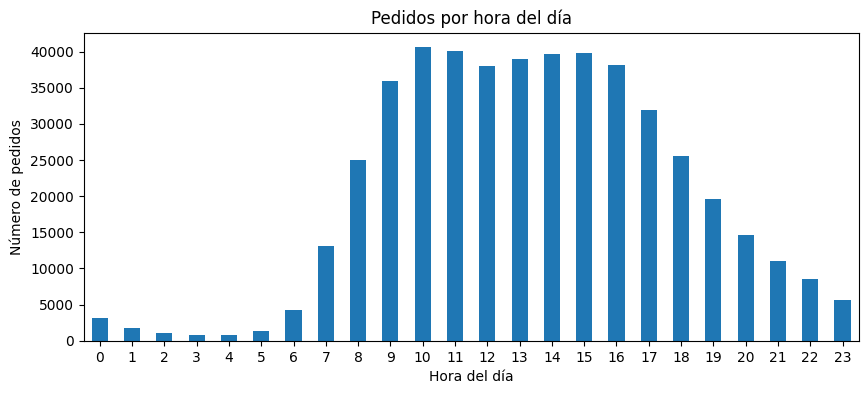

In [61]:
# Queremos saber cuántos pedidos se hacen en cada hora del día.

# Agrupamos los pedidos por la columna 'order_hour_of_day'
pedidos_por_hora = instacart_orders.groupby('order_hour_of_day')['order_id'].count()

# Mostramos el resultado en forma de tabla
print(pedidos_por_hora)
print ()
print ()

# Graficamos los pedidos por hora para visualizar las horas con más actividad
pedidos_por_hora.plot(kind='bar', figsize=(10,4), 
                      title='Pedidos por hora del día', 
                      xlabel='Hora del día',
                      ylabel='Número de pedidos',
                      rot=0
                     )

Se observa un mayor número de pedidos entre las 9 a.m. y 5 p.m., lo que coincide con los horarios laborales y de compra cotidiana.

### [A3] ¿Qué día de la semana compran víveres las personas?

order_dow
0    84090
1    82185
2    65833
3    60912
4    59810
5    63488
6    62649
Name: order_id, dtype: int64




<AxesSubplot:title={'center':'Pedidos por día de la semana'}, xlabel='Día de la semana', ylabel='Número de pedidos'>

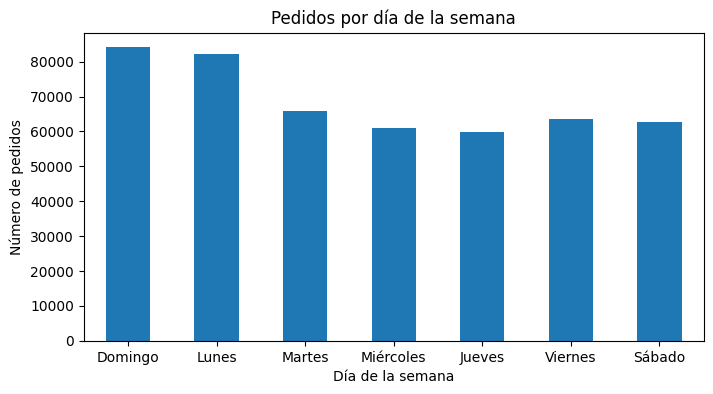

In [62]:
# Analizamos cuántos pedidos se hacen según el día de la semana.

# Agrupamos los pedidos por la columna 'order_dow'
pedidos_por_dia = instacart_orders.groupby('order_dow')['order_id'].count()

# Mostramos la cantidad de pedidos por día
print(pedidos_por_dia)
print ()
print ()

# Graficamos para identificar el día con más pedidos

# Crear un mapeo de números a días
dias_semana = {0: 'Domingo', 1: 'Lunes', 2: 'Martes', 3: 'Miércoles',
            4: 'Jueves', 5: 'Viernes', 6: 'Sábado'}

# Cambiar el índice del DataFrame
pedidos_por_dia.index = pedidos_por_dia.index.map(dias_semana)

pedidos_por_dia.plot(kind='bar', 
                     figsize=(8,4), 
                     title='Pedidos por día de la semana',
                    xlabel='Día de la semana',
                     ylabel='Número de pedidos',
                    rot=0
                 )



Los datos suelen mostrar mayor número de pedidos entre viernes y domingo, lo que refleja un patrón de compra de fin de semana, cuando las personas se abastecen para los próximos días.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

Tiempo mínimo entre pedidos: 0.0 días
Tiempo máximo entre pedidos: 30.0 días
Promedio de espera entre pedidos: 11.10 días




<AxesSubplot:title={'center':'Tiempo que las personas esperan para hacer su siguiente pedido'}, xlabel='Días desde el pedido anterior', ylabel='Número de pedidos'>

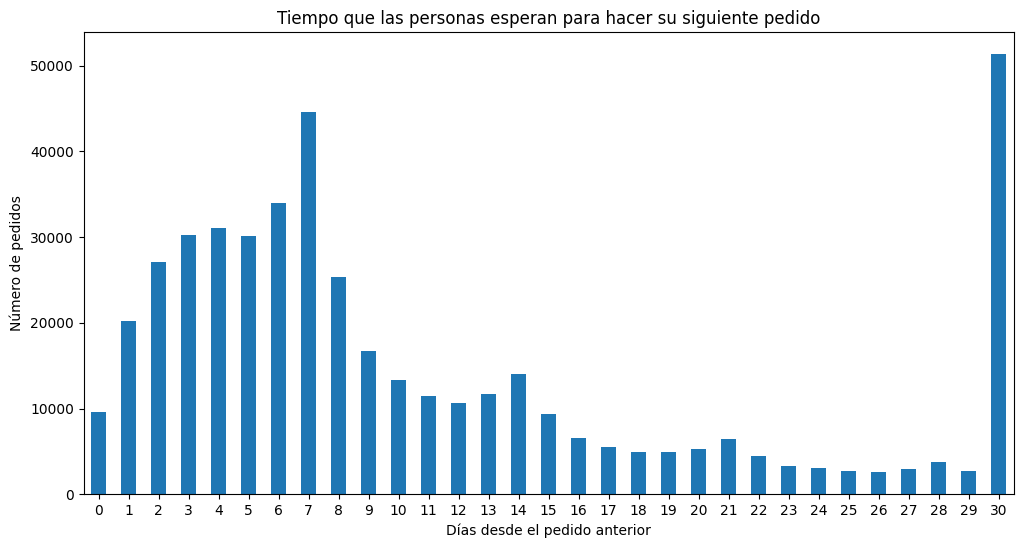

In [63]:
# Analizamos el tiempo promedio y los extremos entre pedidos.

# Revisar los valores mínimo y máximo de 'days_since_prior_order'
min_days = instacart_orders['days_since_prior_order'].min()   # Tiempo mínimo entre pedidos
max_days = instacart_orders['days_since_prior_order'].max()   # Tiempo máximo entre pedidos
mean_days = instacart_orders['days_since_prior_order'].mean() # Promedio de espera

# Imprimir los resultados
print(f"Tiempo mínimo entre pedidos: {min_days} días")
print(f"Tiempo máximo entre pedidos: {max_days} días")
print(f"Promedio de espera entre pedidos: {mean_days:.2f} días")
print()
print()

# Creamos un gráfico de barras que muestre cuántos pedidos corresponden a cada intervalo de días
instacart_orders['days_since_prior_order'].value_counts().sort_index().plot(kind='bar', 
                                                                            figsize=(12,6),
                                                                            title='Tiempo que las personas esperan para hacer su siguiente pedido',
                                                                            xlabel='Días desde el pedido anterior',
                                                                            ylabel='Número de pedidos',
                                                                            rot=0,
                                                                            xticks =range(0,31,1))

El análisis muestra que el tiempo de espera entre pedidos varía entre 0 y 30 días, con un promedio de 11,1 días. La mayoría de los usuarios realiza su siguiente compra dentro de la primera semana, especialmente entre los días 3 y 7, lo que sugiere un patrón de recompra semanal típico de productos de consumo frecuente. Los valores máximos (30 días) podrían corresponder a clientes ocasionales o compras mensuales planificadas. En general, los datos reflejan hábitos de compra regulares y coherentes con el comportamiento esperado de consumidores recurrentes.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [64]:
# Filtrar los pedidos hechos en miércoles (3) y sábados (6)
miercoles = instacart_orders[instacart_orders['order_dow'] == 3]
sabado = instacart_orders[instacart_orders['order_dow'] == 6]

In [65]:
# Contar cuántos pedidos se hacen en cada hora del día para ambos días
miercoles_horas = miercoles['order_hour_of_day'].value_counts().sort_index()
sabado_horas = sabado['order_hour_of_day'].value_counts().sort_index()


In [66]:
# Crear DataFrame con información adicional
# Se construye una tabla que contiene las horas del día (0 a 23) y la cantidad de pedidos
# para los miércoles y sábados, usando las series que ya habíamos calculado antes
tabla_comparacion = pd.DataFrame({
    'Hora': range(24),           # Crea una columna con los números del 0 al 23
    'Miércoles': miercoles_horas,  # Agrega la serie con los pedidos por hora de los miércoles
    'Sábado': sabado_horas         # Agrega la serie con los pedidos por hora de los sábados
})

# Agregar columna de diferencia
# Calcula la diferencia entre los pedidos del sábado y los del miércoles en cada hora
tabla_comparacion['Diferencia'] = tabla_comparacion['Sábado'] - tabla_comparacion['Miércoles']

# Mostrar la tabla completa con los resultados, sin el ìndice del DataFrame
print(tabla_comparacion.to_string(index=False))

# Mostrar el total de pedidos en miércoles
print(f"\nTotal Miércoles: {tabla_comparacion['Miércoles'].sum()}")

# Mostrar el total de pedidos en sábado
print(f"Total Sábado: {tabla_comparacion['Sábado'].sum()}")


 Hora  Miércoles  Sábado  Diferencia
    0        373     464          91
    1        215     254          39
    2        121     177          56
    3        101     125          24
    4        108     118          10
    5        170     161          -9
    6        643     451        -192
    7       1732    1619        -113
    8       3125    3246         121
    9       4490    4311        -179
   10       5026    4919        -107
   11       5004    5116         112
   12       4688    5132         444
   13       4674    5323         649
   14       4774    5375         601
   15       5163    5188          25
   16       4976    5029          53
   17       4175    4295         120
   18       3463    3338        -125
   19       2652    2610         -42
   20       1917    1847         -70
   21       1450    1473          23
   22       1154    1185          31
   23        718     893         175

Total Miércoles: 60912
Total Sábado: 62649


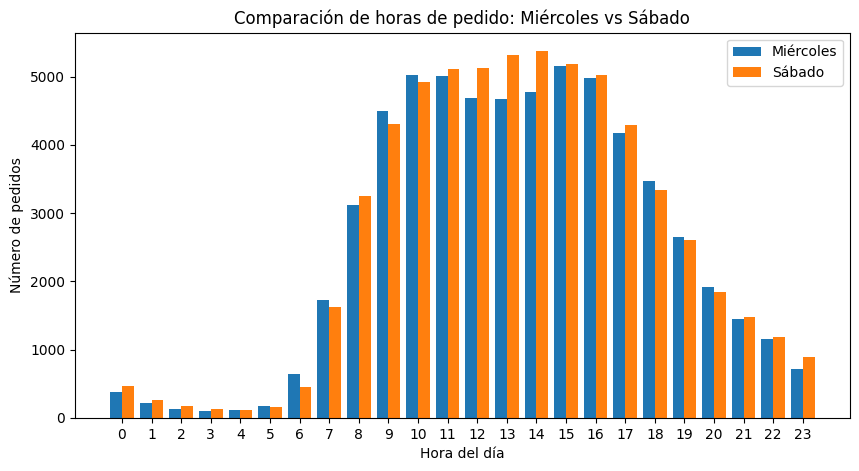

In [67]:
# Crear un gráfico para comparar ambas distribuciones en el mismo gráfico
plt.figure(figsize=(10,5))  # tamaño del gráfico
plt.bar(miercoles_horas.index - 0.2, miercoles_horas.values, width=0.4, label='Miércoles')
plt.bar(sabado_horas.index + 0.2, sabado_horas.values, width=0.4, label='Sábado')

# Agregar título, etiquetas y leyenda
plt.title('Comparación de horas de pedido: Miércoles vs Sábado')
plt.xlabel('Hora del día')
plt.ylabel('Número de pedidos')
plt.xticks(range(0,24,1))
plt.legend()
plt.show()

Al comparar los patrones de pedidos entre miércoles y sábado, se observa que ambos días presentan una distribución similar en cuanto a las horas de mayor actividad. Los pedidos comienzan a aumentar a partir de las 7 a.m., alcanzando su punto máximo entre las 10 a.m. y 3 p.m., y disminuyen progresivamente hacia la noche.

Sin embargo, los miércoles registran un mayor volumen total de pedidos (69.912) frente a los sábados (62.649), lo que indica que, aunque las tendencias horarias son parecidas, los días laborales tienen una demanda ligeramente superior.

La diferencia más notable se presenta en las primeras horas del día (7–10 a.m.), donde los miércoles tienen más actividad, mientras que los sábados tienden a tener picos un poco más concentrados hacia el mediodía.

En resumen, los clientes mantienen hábitos de compra consistentes durante la semana, pero con un leve descenso en fines de semana, posiblemente por cambios en la rutina o menor necesidad de abastecimiento.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [68]:
# Contar cuántos pedidos hizo cada cliente
pedidos_por_cliente = instacart_orders['user_id'].value_counts()

# Contar cuántos clientes tienen 1 pedido, 2 pedidos, etc.
distribucion = pedidos_por_cliente.value_counts().sort_index()

print(distribucion)

1     55355
2     36508
3     21548
4     13498
5      8778
6      6012
7      4240
8      3016
9      2153
10     1646
11     1308
12      948
13      701
14      514
15      437
16      263
17      184
18      121
19       85
20       52
21       22
22       23
23       19
24        3
25        1
26        1
28        1
Name: user_id, dtype: int64


In [69]:
# Calcular estadísticas precisas
total_clientes = distribucion.sum()
pedidos_1_a_3 = distribucion[0:2].sum()  # Clientes con 1, 2 y 3 pedidos
pedidos_mas_10 = distribucion[distribucion.index >= 10].sum()  # Clientes con 10 o más pedidos

# Calcular porcentajes exactos
porcentaje_1_a_3 = (pedidos_1_a_3 / total_clientes) * 100
porcentaje_mas_10 = (pedidos_mas_10 / total_clientes) * 100


print(f"Total de clientes: {total_clientes:,}")
print(f"Clientes con 1-3 pedidos: {pedidos_1_a_3:,} ({porcentaje_1_a_3:.1f}%)")
print(f"Clientes con 10 o más pedidos: {pedidos_mas_10:,} ({porcentaje_mas_10:.1f}%)")


Total de clientes: 157,437
Clientes con 1-3 pedidos: 91,863 (58.3%)
Clientes con 10 o más pedidos: 6,329 (4.0%)


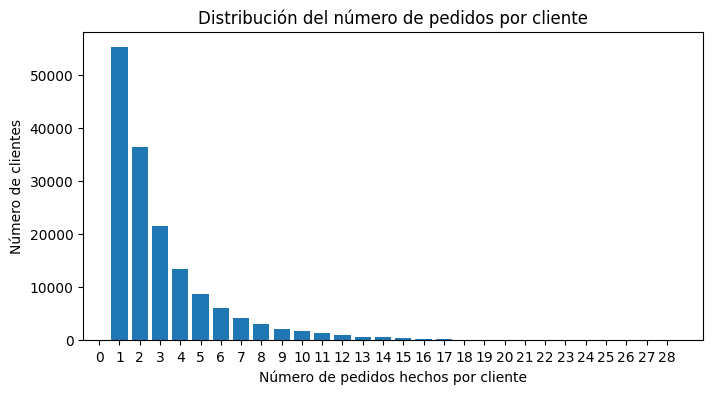

In [70]:
# Graficar la distribución
plt.figure(figsize=(8,4))
plt.bar(distribucion.index, distribucion.values)
plt.title('Distribución del número de pedidos por cliente')
plt.xlabel('Número de pedidos hechos por cliente')
plt.ylabel('Número de clientes')
plt.xticks(range(0,29,1))
plt.show()

La distribución del número de pedidos por cliente muestra una tendencia fuertemente decreciente, donde la mayoría de los usuarios realizan pocos pedidos. En total, se registraron 157.437 clientes, de los cuales el 58,3 % (91.863 clientes) han hecho entre 1 y 3 pedidos, evidenciando un comportamiento de compra esporádico o de prueba. En contraste, solo 4,0 % (6.329 clientes) han realizado 10 o más pedidos, lo que sugiere un grupo reducido pero potencialmente más fiel o recurrente.

En la gráfica se observa que las primeras barras (correspondientes a entre 1 y 5 pedidos) concentran la mayor parte de los clientes, mientras que los valores más altos apenas se perciben debido a su baja frecuencia —algunos corresponden incluso a un único cliente. Esto confirma que la base de usuarios está compuesta principalmente por compradores ocasionales, mientras que los clientes de alta frecuencia representan una minoría significativa para estrategias de fidelización y segmentación.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [71]:
# Contar cuántas veces aparece cada producto_id en el conjunto de datos de pedidos
top_productos = order_products['product_id'].value_counts().head(20)


In [72]:
# Combinar los IDs con sus nombres para obtener la información completa
top_productos_df = pd.DataFrame({'product_id': top_productos.index, 'n_veces_pedido': top_productos.values})
top_productos_df = top_productos_df.merge(products, on='product_id', how='left')


In [73]:
# Mostrar los 20 productos más populares (ID y nombre)
print(top_productos_df[['product_id', 'product_name', 'n_veces_pedido']])

    product_id              product_name  n_veces_pedido
0        24852                    Banana           66050
1        13176    Bag of Organic Bananas           53297
2        21137      Organic Strawberries           37039
3        21903      Organic Baby Spinach           33971
4        47209      Organic Hass Avocado           29773
5        47766           Organic Avocado           24689
6        47626               Large Lemon           21495
7        16797              Strawberries           20018
8        26209                     Limes           19690
9        27845        Organic Whole Milk           19600
10       27966       Organic Raspberries           19197
11       22935      Organic Yellow Onion           15898
12       24964            Organic Garlic           15292
13       45007          Organic Zucchini           14584
14       39275       Organic Blueberries           13879
15       49683            Cucumber Kirby           13675
16       28204        Organic F

El análisis de los 20 productos más populares evidencia una clara preferencia de los clientes por frutas y vegetales frescos, en especial aquellos con características orgánicas. El producto más solicitado es la banana, con 66.650 pedidos, seguida por la bolsa de bananas orgánicas (53.297 pedidos) y las fresas orgánicas (37.039 pedidos).

Esta tendencia sugiere que los consumidores priorizan alimentos básicos, saludables y de consumo frecuente, especialmente dentro de la categoría de productos orgánicos. De hecho, la mayoría de los artículos del top 20 pertenecen a esta categoría, lo cual refleja una inclinación hacia hábitos de compra más saludables y sostenibles.

Además, la variedad dentro del listado (que incluye frutas, vegetales, y algunos productos derivados como la leche orgánica o el ajo) indica que los clientes valoran tanto la frescura como la disponibilidad constante de productos esenciales para su alimentación diaria.

En conjunto, los resultados permiten concluir que la demanda está fuertemente concentrada en productos frescos y orgánicos, lo que puede orientar estrategias de abastecimiento, promociones y fidelización hacia estos segmentos de mayor rotación.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [74]:
# C1: distribución del número de artículos por pedido

# Contar cuántos productos hay en cada pedido (una fila por producto en order_products)
productos_por_pedido = order_products.groupby('order_id')['product_id'].count()
# Mostrar estadísticas resumen (min, 25%, 50%, mean, 75%, max)
print("Estadísticas de productos por pedido:")
print(productos_por_pedido.describe())

Estadísticas de productos por pedido:
count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
Name: product_id, dtype: float64


In [75]:
# Mostrar la distribución: cuántos pedidos tienen x productos
dist_productos_por_pedido = productos_por_pedido.value_counts().sort_index()
print("Distribución (número de pedidos por cantidad de productos):")
print(dist_productos_por_pedido.head(20))  # primeras 20 filas para ver lo más común


Distribución (número de pedidos por cantidad de productos):
1     21847
2     26292
3     29046
4     31054
5     31923
6     31698
7     30822
8     28539
9     25742
10    23248
11    20406
12    18539
13    16497
14    14472
15    12696
16    11465
17    10002
18     8726
19     7612
20     6771
Name: product_id, dtype: int64


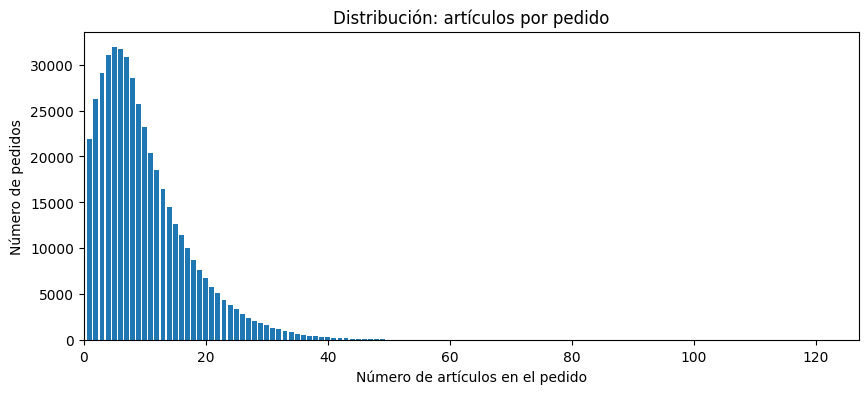

In [76]:
# Graficar la distribución
import matplotlib.pyplot as plt
plt.figure(figsize=(10,4))
plt.bar(dist_productos_por_pedido.index, dist_productos_por_pedido.values)
plt.title('Distribución: artículos por pedido')
plt.xlabel('Número de artículos en el pedido')
plt.ylabel('Número de pedidos')
plt.xlim(0, dist_productos_por_pedido.index.max())  # ajustar eje x
plt.show()


El análisis muestra que, en promedio, los clientes compran aproximadamente 10 artículos por pedido, con una mediana de 8 productos, lo que indica que la mayoría de las compras son relativamente pequeñas. La distribución es asimétrica a la derecha (sesgada), ya que aunque existen pedidos con más de 100 productos, estos son muy poco frecuentes.

Los resultados estadísticos evidencian que el 50% de los pedidos contienen entre 5 y 14 artículos, concentrándose la mayor parte de las compras en este rango. Además, la gráfica confirma que los pedidos con pocos artículos (entre 5 y 10) son los más comunes, mientras que la frecuencia disminuye rápidamente a medida que aumenta el número de productos.

En general, se puede concluir que los clientes de la plataforma suelen realizar compras moderadas y frecuentes, más orientadas al reabastecimiento de productos cotidianos que a compras masivas.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [77]:
# C2: top 20 productos por número de veces que fueron reordenados (sum of reordered)

# Sumar la columna 'reordered' por product_id para obtener cuántas veces fue reordenado cada producto
reorders_por_producto = order_products.groupby('product_id')['reordered'].sum()

In [78]:
# Tomar los 20 productos con mayor número de reordenes
top20_reorders = reorders_por_producto.sort_values(ascending=False).head(20)

In [79]:
# Convertir a DataFrame y unir con la tabla products para obtener el nombre
top20_reorders_df = top20_reorders.reset_index().rename(columns={'reordered':'n_veces_reordenado'})
top20_reorders_df = top20_reorders_df.merge(products[['product_id','product_name']], on='product_id', how='left')



In [80]:
# Mostrar resultado: product_id, product_name, veces_reordenado
print(top20_reorders_df[['product_id','product_name','n_veces_reordenado']])

    product_id              product_name  n_veces_reordenado
0        24852                    Banana               55763
1        13176    Bag of Organic Bananas               44450
2        21137      Organic Strawberries               28639
3        21903      Organic Baby Spinach               26233
4        47209      Organic Hass Avocado               23629
5        47766           Organic Avocado               18743
6        27845        Organic Whole Milk               16251
7        47626               Large Lemon               15044
8        27966       Organic Raspberries               14748
9        16797              Strawberries               13945
10       26209                     Limes               13327
11       22935      Organic Yellow Onion               11145
12       24964            Organic Garlic               10411
13       45007          Organic Zucchini               10076
14       49683            Cucumber Kirby                9538
15       28204        Or

Los resultados muestran que los productos que los usuarios vuelven a pedir con mayor frecuencia son en su mayoría frutas y vegetales frescos, encabezados por el Banano (ID 24852), seguido por el Bag of Organic Bananas (ID 13176) y las Organic Strawberries (ID 21137). Estos artículos presentan las cifras más altas de “reordenados”, lo que indica que son productos de compra rutinaria dentro del comportamiento de los clientes.

La lista evidencia una clara preferencia por productos orgánicos y de consumo recurrente, tales como espinacas, aguacates, leche orgánica y cebollas, lo que sugiere que los usuarios confían en la calidad de estos productos y los integran de forma constante en su canasta básica.

Al comparar los productos más reordenados con los más vendidos, se observa una coincidencia casi total en los primeros lugares, lo que confirma que los artículos más populares también son los más reincidentes en las compras. Esto demuestra que los hábitos de consumo son consistentes: los productos más comprados son también los más repetidos, reflejando fidelidad hacia ciertos productos esenciales y saludables dentro del catálogo.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [81]:
# C3: tasa de repetición por producto = sum(reordered) / total_pedidos_del_producto

# Contar cuántas veces aparece cada producto (total pedidos del producto)
total_por_producto = order_products.groupby('product_id')['product_id'].count()

# Sumar reordenes por producto (veces que fue pedido como reorden)
reorders_por_producto = order_products.groupby('product_id')['reordered'].sum()


In [82]:
# Calcular tasa (reorders / total)
tasa_repeticion = (reorders_por_producto / total_por_producto).fillna(0)

In [83]:
# Crear DataFrame ordenado por tasa descendente (y mostrar top 10)
tasa_df = tasa_repeticion.reset_index().rename(columns={0:'tasa_repeticion', 'reordered':'n_veces_reordenado'})
tasa_df.columns = ['product_id', 'tasa_repeticion']
tasa_df = tasa_df.merge(products[['product_id','product_name']], on='product_id', how='left')
tasa_df = tasa_df.sort_values('tasa_repeticion', ascending=False)

print("Top 10 productos por tasa de repetición (proporción de pedidos que son reordenes):")
print()
print(tasa_df[['product_id','product_name','tasa_repeticion']].head(10))

Top 10 productos por tasa de repetición (proporción de pedidos que son reordenes):

       product_id                                       product_name  \
13453       14721                            Bone Strength Take Care   
19195       20949                           Vanilla Sandwich Cookies   
6136         6723                                   Palmiers- Petite   
6144         6732                  Naturally Sparkling Mineral Water   
41319       45088  California Dill Pollen & Garlic Goat Cheese & ...   
41310       45078                                       Pomegranatea   
19258       21016       Parchment Lined 8 in x 3.75 in x 2.5 in Pans   
19248       21005                        Peanut Butter Pie Ice Cream   
32273       35192                         Chocolate Soy Milk Singles   
32277       35197  Mocha Chocolate Chip  Organic Non-Dairy Frozen...   

       tasa_repeticion  
13453              1.0  
19195              1.0  
6136               1.0  
6144               1.0 

Los resultados muestran que existen productos con una tasa de repetición del 100%, es decir, todos los clientes que los compraron en algún momento los volvieron a pedir en pedidos posteriores. Entre estos se destacan artículos como Bone Strength Take Care, Vanilla Sandwich Cookies, California Dill Pollen & Garlic Goat Cheese & Crackers y Peanut Butter Pie Ice Cream.

Esto indica que estos productos generan una fidelidad total del consumidor, ya sea por su calidad, utilidad o carácter de consumo recurrente. En general, los productos con alta tasa de repetición tienden a ser snacks, bebidas y productos de consumo habitual, lo que sugiere una fuerte preferencia y hábito de recompra.

En conjunto, la alta tasa de repetición refleja que una parte importante del catálogo de Instacart está compuesta por productos que los clientes integran a su rutina de compras, lo cual representa una gran oportunidad para estrategias de retención y recomendación personalizada.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [84]:
# C4: para cada usuario calcular tasa_usuario = sum(reordered) / total_productos_pedidos_por_usuario


# Primero, unir order_products con instacart_orders para obtener user_id
order_products_con_usuario = order_products.merge(instacart_orders[['order_id', 'user_id']], on='order_id')

# Para cada user_id contar total de filas (productos pedidos)
total_por_usuario = order_products_con_usuario.groupby('user_id')['product_id'].count()

# Para cada user_id sumar la columna 'reordered' (cuántos ítems fueron reordenes)
reorders_por_usuario = order_products_con_usuario.groupby('user_id')['reordered'].sum()

# Calcular la tasa por usuario (proporción de sus productos que son reordenes)
tasa_usuario = (reorders_por_usuario / total_por_usuario).fillna(0)

In [85]:
# Estadísticas de la tasa por usuario y ejemplo de la distribución
print("Estadísticas de la tasa de reorden por usuario:")
print(tasa_usuario.describe())


Estadísticas de la tasa de reorden por usuario:
count    149626.000000
mean          0.494853
std           0.292685
min           0.000000
25%           0.272727
50%           0.500000
75%           0.724138
max           1.000000
dtype: float64


En promedio, cada cliente había vuelto a pedir aproximadamente la mitad de los productos que compró (tasa media de reorden del 49,5 %). Esto indica que existe una fuerte tendencia a la recompra, ya que muchos usuarios repiten con frecuencia los mismos artículos.  

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [86]:
# C5: top 20 productos que aparecen en la posición 1 del carrito

# Filtrar filas donde add_to_cart_order == 1 (primer artículo añadido)
primeros = order_products[order_products['add_to_cart_order'] == 1]

# Contar cuántas veces cada product_id fue el primero
primeros_cont = primeros['product_id'].value_counts().head(20)

In [87]:
# Pasar a DataFrame y unir con products para obtener nombres
primeros_df = primeros_cont.reset_index().rename(columns={'index':'product_id','product_id':'veces_primer_pos'})
primeros_df = primeros_df.merge(products[['product_id','product_name']], on='product_id', how='left')

In [88]:
# Mostrar product_id, product_name y veces que fue el primero
print(primeros_df[['product_id','product_name','veces_primer_pos']])

    product_id                 product_name  veces_primer_pos
0        24852                       Banana             15562
1        13176       Bag of Organic Bananas             11026
2        27845           Organic Whole Milk              4363
3        21137         Organic Strawberries              3946
4        47209         Organic Hass Avocado              3390
5        21903         Organic Baby Spinach              3336
6        47766              Organic Avocado              3044
7        19660                 Spring Water              2336
8        16797                 Strawberries              2308
9        27966          Organic Raspberries              2024
10       44632   Sparkling Water Grapefruit              1914
11       49235          Organic Half & Half              1797
12       47626                  Large Lemon              1737
13         196                         Soda              1733
14       38689     Organic Reduced Fat Milk              1397
15      

Los 20 principales artículos que las personas ponen primero en sus carritos incluyen productos como Banana, Bag of Organic Bananas, Organic Whole Milk, Organic Strawberries, Organic Baby Spinach, Large Lemon, Avocado, y Organic Raspberries, entre otros. Estos resultados muestran una clara preferencia por productos frescos, orgánicos y de consumo frecuente, especialmente frutas, vegetales y lácteos.

Al comparar con los productos más vendidos y los más reordenados, se observa una fuerte coincidencia: muchos de los productos que las personas añaden primero al carrito también son los más comprados y los que más se vuelven a pedir. Esto sugiere que los consumidores suelen comenzar sus compras con artículos básicos y recurrentes, probablemente aquellos que forman parte de su consumo habitual y en los que confían por su calidad o necesidad frecuente. En resumen, los primeros productos del carrito reflejan tanto la rutina de compra como la fidelidad hacia ciertos alimentos esenciales.

### Conclusion general del proyecto:

El análisis integral del conjunto de datos de Instacart permitió obtener una comprensión profunda del comportamiento de compra de los usuarios, sus patrones de recompra y los productos con mayor rotación. Durante las fases de descripción, limpieza y análisis, se procesaron más de 478.967 órdenes, 49.000 productos, 134 pasillos y 21 departamentos, garantizando la integridad del dataset mediante la corrección de tipos, el tratamiento de valores ausentes y la depuración de duplicados.

Durante la limpieza, se detectaron 28.819 valores nulos (6%) en days_since_prior_order —correspondientes a primeros pedidos—, 1.258 nombres de productos faltantes (2,5%) sustituidos por “Unknown”, y 836 valores ausentes (0,018%) en add_to_cart_order, reemplazados por 999. Estas acciones aseguraron una base sólida y confiable para el análisis posterior.

En la fase analítica, se identificó que el mayor pico de pedidos ocurre a las 10:00 a.m. (40.578 pedidos), manteniéndose una alta actividad hasta las 4:00 p.m., lo que revela un comportamiento matutino y constante en las compras. En cuanto a los días de la semana, el domingo concentra el mayor número de pedidos (84.090), seguido por el lunes (82.185), mientras que la actividad disminuye levemente hacia mitad y fin de semana. Estos hallazgos sugieren que los usuarios tienden a realizar compras estratégicas al inicio de la semana, posiblemente para abastecer sus hogares.

El análisis de distribución de clientes mostró que el 58,3% realiza entre 1 y 3 pedidos, mientras que solo el 4,0% efectúa más de 10, lo que evidencia una base amplia de compradores ocasionales y un segmento más reducido pero altamente fiel. En promedio, cada pedido contiene 10 productos, con un rango de 1 a 127 artículos, lo que indica que las compras suelen ser de reposición más que de acopio.

En términos de lealtad, se observó que el 59,05% de los productos fueron reordenados y que, en promedio, los clientes vuelven a pedir el 49,5% de los artículos que ya habían adquirido, lo cual demuestra un fuerte hábito de recompra. Los productos más populares, reordenados y primeros en el carrito pertenecen a categorías de alimentos frescos y orgánicos, como bananas, espinacas, aguacates y leche, consolidando una preferencia hacia productos básicos y saludables.

En conjunto, los resultados reflejan un ecosistema de clientes consistentes, previsibles y con hábitos definidos de consumo recurrente. Este análisis ofrece a Instacart información estratégica para optimizar sus modelos de recomendación personalizada, mejorar la gestión del inventario según los picos horarios y diarios identificados, y fortalecer las estrategias de fidelización y segmentación, aprovechando tanto a los usuarios ocasionales como a los recurrentes de alto valor.